<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Problem_Set_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1: Data Preparation**

In [10]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv('churn_synthetic_600_new.csv')
df.head()

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,23,77.81,Month-to-Month,Credit Card,1
1,C0002,0,33,69.65,One-Year,Credit Card,1
2,C0003,1,22,64.27,Month-to-Month,Electronic Check,2
3,C0004,1,4,66.30,Month-to-Month,Credit Card,3
4,C0005,0,2,60.82,One-Year,Bank Transfer,1


In [11]:
print(df.dtypes)
print(df.shape)

X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

numeric_features = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
categorical_features = ['ContractType', 'PaymentMethod']

CustomerID        object
Churn              int64
TenureMonths       int64
MonthlyCharge    float64
ContractType      object
PaymentMethod     object
SupportCalls       int64
dtype: object
(600, 7)


In [12]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_features)
], remainder='passthrough')

Decision Trees split the data based on feature values, not on distance-based calculations. We use OneHotEncoder to split the categories into binary columns that the model can actually read since it needs numbers to work with, not labels.

**Part 2: Decison Tree Model Construction**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=12, min_samples_leaf=18, random_state=42))
])

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=12, min_samples_leaf=18,
                                        random_state=42))])

Decision Trees ask a sequence of yes or no questions about specific features until it reaches a leaf and assigns a class. In contrast, Logistic Regression learns a weighted equation by multiplying each feature by a coefficient, then passing the sum through a sigmoid to obtain the probability.

**Part 3: Default Threshold Evaluation**

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[97  5]
 [15  3]]


In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.8333
Precision: 0.3750
Recall:    0.1667


The confussion matrix model correctly identified that 97 (TN) custumers stayed and predicted that 5 (FP) would churned, but only 3 (TP) actually did. Addtionaly, the model missed 15 (FN) actual churners.

Accuracy of 0.8333 means that the model scored high just by predicting "stayed" most of the time.

Precision of 0.3750 means that when the model predicts churn, it only gets it right 37.5% of the time which is not great.

A recall of 0.1667 means the model only captured 3 of the 18 actual churners. This is the bigger issue with the model, since those misses are customers the company would like to intervene with before losing them. At the moment, the 0.50 threshold default is too conservative.

**Part 4: ROC Curve and AUC**

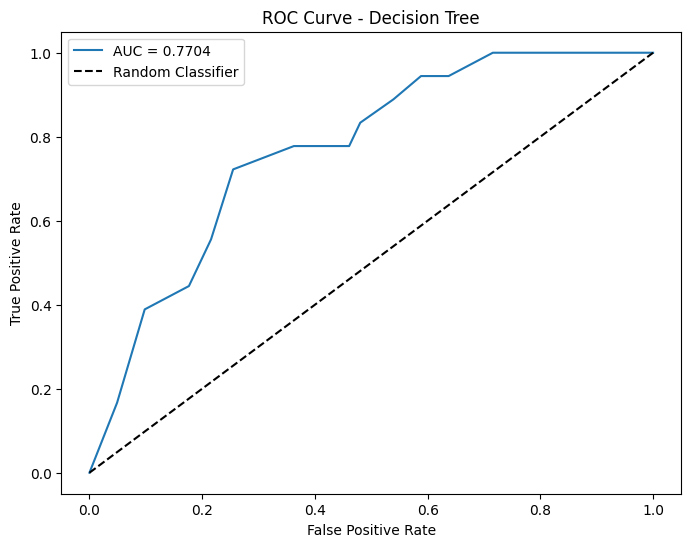

AUC: 0.7704


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

print(f"AUC: {auc:.4f}")

1. What does the ROC curve represent in a classification model? The ROC curve represents the True Positive Rate (TPR) against the False Positive Rate (FPR) for every classification threshold.


2. What does the Area Under the Curve (AUC) measure? The AUC summarizes the entire ROC curve as a percentage; it's how effectively the model discriminates between a churner and a non-churner.


3. What does the AUC for this model tell us? The AUC model correctly identifies 77% of churners compared to non-churners.


4. What would an AUC value close to 1.00 imply? This would be an ideal model. It would almost identifify all churn probabilities rathern than identifying non-churners as churners. This means the model can clearly distinguish the two groups at the specified threshold.


5. Why is ROC analysis useful when classification thresholds can change? The ROC analysis lets us evaluate the model's overall performance and quality before setting a threshold aligned with the company's priorities.



**Part 5: Threshold Optimization Using Youden's J**

**This is my AI input:**

Write Python code that computes TPR and FPR across a range of thresholds using an sklearn ROC curve output, then identifies the threshold that maximizes Youden's J statistic, defined as J = TPR - FPR. Print the optimal threshold, TPR, FPR, and J value.

In [18]:
import numpy as np

# Compute Youden's J for each threshold
J_scores = tpr - fpr

# Find the index of the maximum J
optimal_idx = np.argmax(J_scores)

# Extract values at that index
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_J = J_scores[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"TPR at optimal:    {optimal_tpr:.4f}")
print(f"FPR at optimal:    {optimal_fpr:.4f}")
print(f"Youden's J:        {optimal_J:.4f}")

Optimal Threshold: 0.2308
TPR at optimal:    0.7222
FPR at optimal:    0.2549
Youden's J:        0.4673


Youden's J is defined as TPR − FPR, so maximizing it means finding the threshold where the gap between correctly caught churners and falsely flagged non-churners is largest.

A high J means the model is simultaneously sensitive (catching real churners) and specific (not over-alerting on loyal customers).


At the default threshold of 0.50, this model had a TPR of just 0.1667 and caught only 3 of 18 churners; J would be very low there. By scanning every possible threshold, Youden's J identified 0.2308 as the sweet spot, where TPR jumps to 0.7222 while FPR rises only to 0.2549, yielding a J of 0.4673.


The threshold dropped from 0.50 to 0.23, which makes intuitive sense. Here, it means the model now flags a customer is likely to churn whenever it assigns a probability of at least 23%, rather than requiring 50% confidence. That wider net catches far more actual churners, and J confirms it's the best balance the model can achieve across all thresholds.

**Part 6: Reclassification Using Optimal Threshold**

In [20]:
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

In [21]:
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print("Confusion Matrix (Optimal Threshold):")
print(cm_optimal)

accuracy_opt = accuracy_score(y_test, y_pred_optimal)
precision_opt = precision_score(y_test, y_pred_optimal)
recall_opt = recall_score(y_test, y_pred_optimal)

print(f"Accuracy:  {accuracy_opt:.4f}")
print(f"Precision: {precision_opt:.4f}")
print(f"Recall:    {recall_opt:.4f}")

Confusion Matrix (Optimal Threshold):
[[76 26]
 [ 5 13]]
Accuracy:  0.7417
Precision: 0.3333
Recall:    0.7222


1. Here we can see that the recall metric improved the most from 0.1667 to 0.7222. Previously, the model only caught 3 out of 18 actual curneres, whereas now it will catch 13 out of 18. This improvement was possibly due to adding the **y_pred_optimal = (y_prob >= optimal_threshold).astype(int)** code seen above.

2. Both Accuracy and Precision metrics decreased. Accuracy dropped from 0.8333 to 0.7417, and Precision dropped from 0.3750 to 0.3333.

3. I believe the threshold of 0.2308 is the better option to deploy. Missing a churner is way more costly than false alarms in most cases. As discussed in previous problems and scenarios in class, a wrongly flagged customer who receives a retention offer is less of a risk than a missed churner, who causes revenue loss.